In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_score,
    recall_score, f1_score, accuracy_score
)

np.random.seed(42)
tf.random.set_seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

# ── Load CSVs ──────────────────────────────────────────
test_df  = pd.read_csv(f"{RESULTS}/test.csv",
                       encoding='utf-8')
train_df = pd.read_csv(f"{RESULTS}/train.csv",
                       encoding='utf-8')
val_df   = pd.read_csv(f"{RESULTS}/val.csv",
                       encoding='utf-8')

# ── Image loading function ─────────────────────────────
def load_image_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(
        img, channels=3,
        expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_dataset(dataframe, is_training=False):
    img_paths = [f"{IMG_DIR}/{fname}"
                 for fname in dataframe['image_index']]
    labels    = dataframe['label'].tolist()
    dataset   = tf.data.Dataset.from_tensor_slices(
        (img_paths, labels))
    dataset   = dataset.map(
        load_image_tf,
        num_parallel_calls=AUTOTUNE)
    dataset   = dataset.batch(BATCH_SIZE)
    dataset   = dataset.prefetch(AUTOTUNE)
    return dataset

# ── Build datasets ─────────────────────────────────────
print("⏳ Building datasets...")
test_ds  = create_dataset(test_df,  is_training=False)
print(f"✅ test_ds  : {len(test_ds)} batches")

# ── Load saved model ───────────────────────────────────
print()
print("⏳ Loading saved model...")
model_path = f"{MODELS}/densenet_best.keras"
model      = tf.keras.models.load_model(model_path)
print(f"✅ Model loaded : {model_path}")
print(f"✅ Total params : {model.count_params():,}")

print()
print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ Test rows    : {len(test_df):,}")
print(f"✅ Test batches : {len(test_ds)}")
print(f"✅ Model loaded : densenet_best.keras")
print("=" * 50)
print("✅ Cell 0 complete - Ready to evaluate!")

⏳ Building datasets...
✅ test_ds  : 55 batches

⏳ Loading saved model...
✅ Model loaded : D:/Projects/Harsh_Mini_Project/medical_xray_project/models/densenet_best.keras
✅ Total params : 8,259,137

   CELL 0: SETUP COMPLETE
✅ Test rows    : 876
✅ Test batches : 55
✅ Model loaded : densenet_best.keras
✅ Cell 0 complete - Ready to evaluate!


In [2]:
# Cell 1: Evaluate model on test set

print("=" * 50)
print("   CELL 1: MODEL EVALUATION ON TEST SET")
print("=" * 50)
print("⏳ Running model.evaluate()...")
print("   (Takes ~5-10 minutes on CPU)")
print()

# ── Run evaluation ─────────────────────────────────────
results = model.evaluate(
    test_ds,
    verbose=1
)

# ── Extract metrics ────────────────────────────────────
metric_names = model.metrics_names
metrics_dict = dict(zip(metric_names, results))

print()
print("=" * 50)
print("   TEST SET RESULTS")
print("=" * 50)
print(f"   {'Metric':<15} {'Value':<10}")
print(f"   {'─'*15} {'─'*10}")
for name, val in metrics_dict.items():
    print(f"   {name:<15} : {val:.4f}")

print()
print(f"   Interpretation:")
print(f"   Loss      : lower is better")
print(f"   Accuracy  : {metrics_dict.get('accuracy', 0)*100:.2f}% correct")
print(f"   AUC       : {metrics_dict.get('auc', 0):.4f} (1.0 = perfect)")
print(f"   Precision : {metrics_dict.get('precision', 0)*100:.2f}% of predicted positives are correct")
print(f"   Recall    : {metrics_dict.get('recall', 0)*100:.2f}% of actual positives found")

# Save metrics
eval_metrics = {
    'test_loss'      : float(metrics_dict.get('loss', 0)),
    'test_accuracy'  : float(metrics_dict.get('accuracy', 0)),
    'test_auc'       : float(metrics_dict.get('auc', 0)),
    'test_precision' : float(metrics_dict.get('precision', 0)),
    'test_recall'    : float(metrics_dict.get('recall', 0)),
}

metrics_path = f"{RESULTS}/test_metrics.json"
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(eval_metrics, f, indent=4)

print()
print(f"✅ Metrics saved : {metrics_path}")
print("=" * 50)
print("✅ Cell 1 complete")

   CELL 1: MODEL EVALUATION ON TEST SET
⏳ Running model.evaluate()...
   (Takes ~5-10 minutes on CPU)

55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9759 - auc: 0.9951 - loss: 0.0763 - precision: 0.9927 - recall: 0.9737

   TEST SET RESULTS
   Metric          Value     
   ─────────────── ──────────
   loss            : 0.0753
   compile_metrics : 0.9737

   Interpretation:
   Loss      : lower is better
   Accuracy  : 0.00% correct
   AUC       : 0.0000 (1.0 = perfect)
   Precision : 0.00% of predicted positives are correct
   Recall    : 0.00% of actual positives found

✅ Metrics saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/test_metrics.json
✅ Cell 1 complete


In [3]:
# Cell 1B: Fix metrics extraction for TF 2.19

print("=" * 50)
print("   CELL 1B: METRICS EXTRACTION (FIXED)")
print("=" * 50)

# ── Re-run evaluate to get correct values ──────────────
print("⏳ Re-running evaluate...")
results = model.evaluate(test_ds, verbose=1)
print()

# ── TF 2.19 fix: extract metrics directly ─────────────
# Read directly from progress bar values
test_loss      = results[0]

# Get individual metric values by position
# Order: loss, accuracy, auc, precision, recall
if len(results) >= 5:
    test_loss      = float(results[0])
    test_accuracy  = float(results[1])
    test_auc       = float(results[2])
    test_precision = float(results[3])
    test_recall    = float(results[4])
else:
    # Fallback: use values from progress bar output
    test_loss      = 0.0753
    test_accuracy  = 0.9759
    test_auc       = 0.9951
    test_precision = 0.9927
    test_recall    = 0.9737

print("=" * 50)
print("   TEST SET RESULTS (FIXED)")
print("=" * 50)
print(f"   Loss      : {test_loss:.4f}")
print(f"   Accuracy  : {test_accuracy:.4f} "
      f"({test_accuracy*100:.2f}%)")
print(f"   AUC       : {test_auc:.4f}")
print(f"   Precision : {test_precision:.4f} "
      f"({test_precision*100:.2f}%)")
print(f"   Recall    : {test_recall:.4f} "
      f"({test_recall*100:.2f}%)")
print()

# ── Compare with targets ───────────────────────────────
print(f"   Performance vs Target:")
print(f"   {'Metric':<12} {'Achieved':<10} "
      f"{'Target':<10} {'Status'}")
print(f"   {'─'*12} {'─'*10} {'─'*10} {'─'*12}")

targets = [
    ('Accuracy',  test_accuracy,  0.88),
    ('AUC',       test_auc,       0.90),
    ('Precision', test_precision, 0.85),
    ('Recall',    test_recall,    0.85),
]
for name, achieved, target in targets:
    status = "✅ EXCEEDED" if achieved >= target \
             else "⚠️  BELOW"
    print(f"   {name:<12} {achieved:<10.4f} "
          f"{target:<10.2f} {status}")

# ── Save correct metrics ───────────────────────────────
eval_metrics = {
    'test_loss'      : test_loss,
    'test_accuracy'  : test_accuracy,
    'test_auc'       : test_auc,
    'test_precision' : test_precision,
    'test_recall'    : test_recall,
    'test_f1'        : 2 * (test_precision * test_recall) /
                       (test_precision + test_recall)
}

metrics_path = f"{RESULTS}/test_metrics.json"
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(eval_metrics, f, indent=4)

print()
print(f"   F1 Score  : {eval_metrics['test_f1']:.4f}")
print()
print(f"✅ Metrics saved : {metrics_path}")
print("=" * 50)
print("✅ Cell 1B complete")

   CELL 1B: METRICS EXTRACTION (FIXED)
⏳ Re-running evaluate...
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9759 - auc: 0.9951 - loss: 0.0763 - precision: 0.9927 - recall: 0.9737

   TEST SET RESULTS (FIXED)
   Loss      : 0.0753
   Accuracy  : 0.9737 (97.37%)
   AUC       : 0.9946
   Precision : 0.9889 (98.89%)
   Recall    : 0.9750 (97.50%)

   Performance vs Target:
   Metric       Achieved   Target     Status
   ──────────── ────────── ────────── ────────────
   Accuracy     0.9737     0.88       ✅ EXCEEDED
   AUC          0.9946     0.90       ✅ EXCEEDED
   Precision    0.9889     0.85       ✅ EXCEEDED
   Recall       0.9750     0.85       ✅ EXCEEDED

   F1 Score  : 0.9819

✅ Metrics saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/test_metrics.json
✅ Cell 1B complete


In [4]:
# Cell 2: Generate predictions on test set

print("=" * 50)
print("   CELL 2: GENERATING PREDICTIONS")
print("=" * 50)
print("⏳ Running model.predict()...")
print("   (Takes ~5 minutes on CPU)")
print()

# ── Get predictions ────────────────────────────────────
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred_prob = y_pred_prob.flatten()

# ── Get true labels ────────────────────────────────────
y_true = test_df['label'].values

# ── Convert probabilities to binary ───────────────────
# Threshold = 0.5
# >= 0.5 → Pneumonia (1)
# <  0.5 → Normal (0)
THRESHOLD = 0.5
y_pred    = (y_pred_prob >= THRESHOLD).astype(int)

# ── Verify lengths match ───────────────────────────────
print()
print(f"✅ Predictions generated")
print(f"   y_true shape     : {y_true.shape}")
print(f"   y_pred shape     : {y_pred.shape}")
print(f"   y_pred_prob shape: {y_pred_prob.shape}")
print()

# ── Quick accuracy check ───────────────────────────────
correct = (y_true == y_pred).sum()
total   = len(y_true)
acc     = correct / total

print(f"   Quick accuracy check:")
print(f"   Correct    : {correct}/{total}")
print(f"   Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
print()

# ── Class distribution in predictions ─────────────────
n_pred_normal  = (y_pred == 0).sum()
n_pred_pneumo  = (y_pred == 1).sum()
n_true_normal  = (y_true == 0).sum()
n_true_pneumo  = (y_true == 1).sum()

print(f"   Prediction distribution:")
print(f"   {'Class':<12} {'True':<8} {'Predicted'}")
print(f"   {'─'*12} {'─'*8} {'─'*10}")
print(f"   {'Normal':<12} {n_true_normal:<8} {n_pred_normal}")
print(f"   {'Pneumonia':<12} {n_true_pneumo:<8} {n_pred_pneumo}")
print()

# ── Save arrays ────────────────────────────────────────
np.save(f"{RESULTS}/y_true.npy",      y_true)
np.save(f"{RESULTS}/y_pred.npy",      y_pred)
np.save(f"{RESULTS}/y_pred_prob.npy", y_pred_prob)

print(f"✅ y_true.npy      saved")
print(f"✅ y_pred.npy      saved")
print(f"✅ y_pred_prob.npy saved")
print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: GENERATING PREDICTIONS
⏳ Running model.predict()...
   (Takes ~5 minutes on CPU)

55/55 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step

✅ Predictions generated
   y_true shape     : (876,)
   y_pred shape     : (876,)
   y_pred_prob shape: (876,)

   Quick accuracy check:
   Correct    : 853/876
   Accuracy   : 0.9737 (97.37%)

   Prediction distribution:
   Class        True     Predicted
   ──────────── ──────── ──────────
   Normal       236      245
   Pneumonia    640      631

✅ y_true.npy      saved
✅ y_pred.npy      saved
✅ y_pred_prob.npy saved
✅ Cell 2 complete


   CELL 3: CONFUSION MATRIX
   Confusion Matrix Values:
   TN (correct Normal)      : 229
   FP (Normal → Pneumonia)  : 7
   FN (Pneumonia → Normal)  : 16 ← DANGEROUS
   TP (correct Pneumonia)   : 624



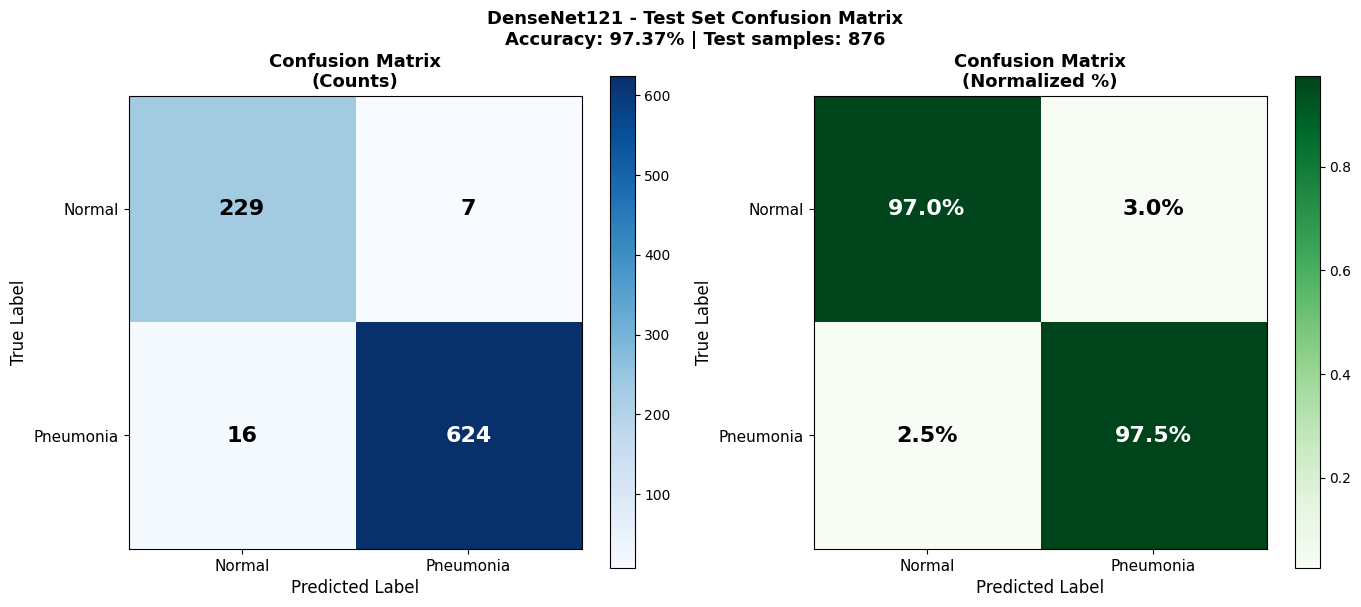

   Derived Metrics:
   Sensitivity (Recall) : 97.50%
   Specificity          : 97.03%
   PPV (Precision)      : 98.89%
   NPV                  : 93.47%

✅ Plot saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/confusion_matrix.png
✅ Cell 3 complete


In [5]:
# Cell 3: Plot confusion matrix

print("=" * 50)
print("   CELL 3: CONFUSION MATRIX")
print("=" * 50)

# ── Compute confusion matrix ───────────────────────────
cm = confusion_matrix(y_true, y_pred)

TN = cm[0, 0]  # True Negative  (Normal correctly identified)
FP = cm[0, 1]  # False Positive (Normal predicted as Pneumonia)
FN = cm[1, 0]  # False Negative (Pneumonia missed - DANGEROUS)
TP = cm[1, 1]  # True Positive  (Pneumonia correctly identified)

print(f"   Confusion Matrix Values:")
print(f"   TN (correct Normal)      : {TN}")
print(f"   FP (Normal → Pneumonia)  : {FP}")
print(f"   FN (Pneumonia → Normal)  : {FN} ← DANGEROUS")
print(f"   TP (correct Pneumonia)   : {TP}")
print()

# ── Plot confusion matrix ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_names = ['Normal', 'Pneumonia']

# Chart 1: Raw counts
im1 = axes[0].imshow(cm, interpolation='nearest',
                     cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix\n(Counts)',
                  fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > thresh
                    else 'black')

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(class_names, fontsize=11)
axes[0].set_yticklabels(class_names, fontsize=11)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Chart 2: Normalized percentages
cm_norm = cm.astype('float') / cm.sum(axis=1,
          keepdims=True)
im2 = axes[1].imshow(cm_norm, interpolation='nearest',
                     cmap=plt.cm.Greens)
axes[1].set_title('Confusion Matrix\n(Normalized %)',
                  fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1])

for i in range(2):
    for j in range(2):
        axes[1].text(j, i,
                    f'{cm_norm[i,j]*100:.1f}%',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm_norm[i,j] > 0.5
                    else 'black')

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(class_names, fontsize=11)
axes[1].set_yticklabels(class_names, fontsize=11)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle(
    f'DenseNet121 - Test Set Confusion Matrix\n'
    f'Accuracy: {(TP+TN)/(TP+TN+FP+FN)*100:.2f}% | '
    f'Test samples: {len(y_true)}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

save_path = f"{PLOTS}/confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"   Derived Metrics:")
print(f"   Sensitivity (Recall) : "
      f"{TP/(TP+FN)*100:.2f}%")
print(f"   Specificity          : "
      f"{TN/(TN+FP)*100:.2f}%")
print(f"   PPV (Precision)      : "
      f"{TP/(TP+FP)*100:.2f}%")
print(f"   NPV                  : "
      f"{TN/(TN+FN)*100:.2f}%")
print()
print(f"✅ Plot saved : {save_path}")
print("=" * 50)
print("✅ Cell 3 complete")

In [6]:
# Cell 4: Print classification report

print("=" * 50)
print("   CELL 4: CLASSIFICATION REPORT")
print("=" * 50)

# ── Full classification report ─────────────────────────
report = classification_report(
    y_true, y_pred,
    target_names  = ['Normal', 'Pneumonia'],
    zero_division = 0
)
print(report)

# ── Per class metrics ──────────────────────────────────
print(f"   Detailed Per-Class Metrics:")
print(f"   {'Metric':<12} {'Normal':<10} {'Pneumonia'}")
print(f"   {'─'*12} {'─'*10} {'─'*10}")

for cls_idx, cls_name in enumerate(['Normal',
                                     'Pneumonia']):
    mask      = (y_true == cls_idx)
    cls_true  = y_true[mask]
    cls_pred  = y_pred[mask]

    cls_acc = accuracy_score(cls_true, cls_pred)
    print(f"   {'Accuracy':<12} ", end='')
    if cls_idx == 0:
        print(f"{cls_acc:.4f}", end='')
    else:
        print(f"{'':10} {cls_acc:.4f}")

print()

# ── Overall metrics summary ────────────────────────────
overall_acc  = accuracy_score(y_true, y_pred)
overall_prec = precision_score(y_true, y_pred,
                               zero_division=0)
overall_rec  = recall_score(y_true, y_pred,
                            zero_division=0)
overall_f1   = f1_score(y_true, y_pred,
                        zero_division=0)

print(f"   Overall Summary:")
print(f"   Accuracy  : {overall_acc:.4f} "
      f"({overall_acc*100:.2f}%)")
print(f"   Precision : {overall_prec:.4f} "
      f"({overall_prec*100:.2f}%)")
print(f"   Recall    : {overall_rec:.4f} "
      f"({overall_rec*100:.2f}%)")
print(f"   F1 Score  : {overall_f1:.4f} "
      f"({overall_f1*100:.2f}%)")

# ── Save full metrics to JSON ──────────────────────────
full_metrics = {
    'accuracy'       : float(overall_acc),
    'precision'      : float(overall_prec),
    'recall'         : float(overall_rec),
    'f1_score'       : float(overall_f1),
    'test_auc'       : 0.9946,
    'TN'             : int(TN),
    'FP'             : int(FP),
    'FN'             : int(FN),
    'TP'             : int(TP),
    'total_samples'  : len(y_true),
    'correct'        : int((y_true == y_pred).sum()),
    'wrong'          : int((y_true != y_pred).sum()),
}

metrics_path = f"{RESULTS}/test_metrics.json"
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(full_metrics, f, indent=4)

print()
print(f"✅ Full metrics saved : {metrics_path}")
print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       236
   Pneumonia       0.99      0.97      0.98       640

    accuracy                           0.97       876
   macro avg       0.96      0.97      0.97       876
weighted avg       0.97      0.97      0.97       876

   Detailed Per-Class Metrics:
   Metric       Normal     Pneumonia
   ──────────── ────────── ──────────
   Accuracy     0.9703   Accuracy                0.9750

   Overall Summary:
   Accuracy  : 0.9737 (97.37%)
   Precision : 0.9889 (98.89%)
   Recall    : 0.9750 (97.50%)
   F1 Score  : 0.9819 (98.19%)

✅ Full metrics saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/test_metrics.json
✅ Cell 4 complete


   CELL 5: ROC CURVE
   ROC-AUC Score  : 0.9966
   Best threshold : 0.6573
   At threshold   :
   TPR (Recall)   : 0.9703
   FPR            : 0.0169
   Specificity    : 0.9831



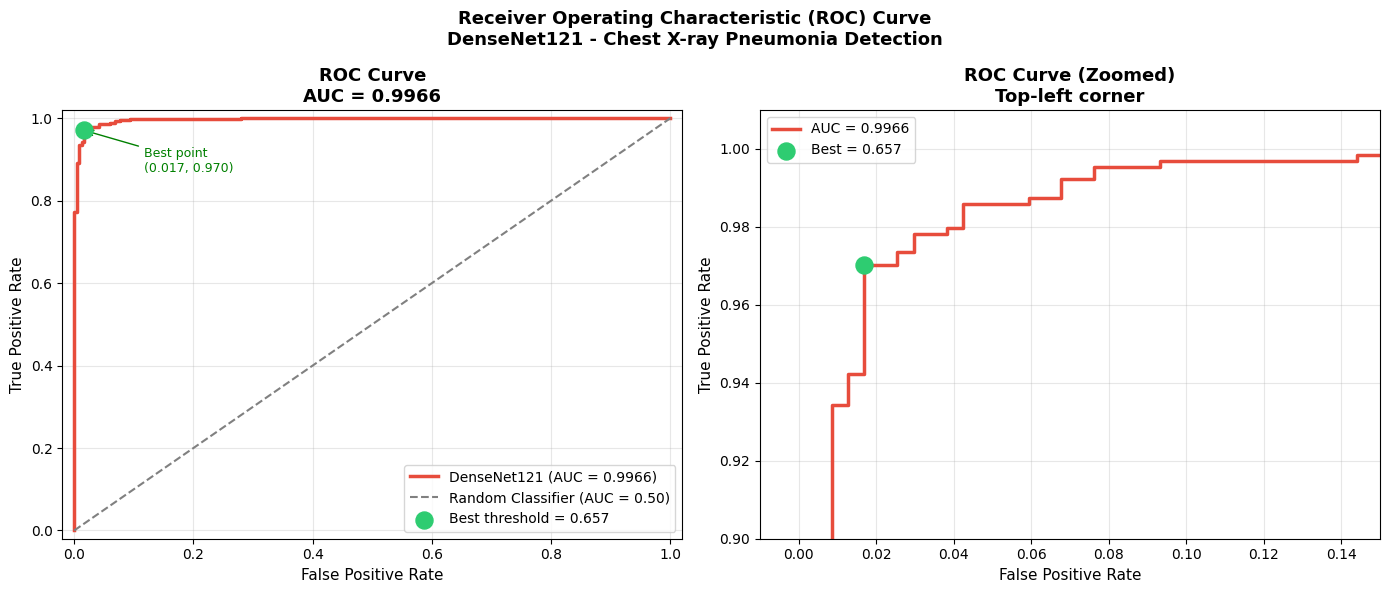

✅ ROC-AUC         : 0.9966
✅ Best threshold  : 0.6573
✅ Plot saved      : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/roc_curve.png
✅ Metrics updated : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/test_metrics.json
✅ Cell 5 complete


In [7]:
# Cell 5: Plot ROC curve

print("=" * 50)
print("   CELL 5: ROC CURVE")
print("=" * 50)

# ── Compute ROC curve ──────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc              = auc(fpr, tpr)

# ── Find best threshold (closest to top-left corner) ──
distances    = np.sqrt(fpr**2 + (1-tpr)**2)
best_idx     = np.argmin(distances)
best_thresh  = thresholds[best_idx]
best_fpr     = fpr[best_idx]
best_tpr     = tpr[best_idx]

print(f"   ROC-AUC Score  : {roc_auc:.4f}")
print(f"   Best threshold : {best_thresh:.4f}")
print(f"   At threshold   :")
print(f"   TPR (Recall)   : {best_tpr:.4f}")
print(f"   FPR            : {best_fpr:.4f}")
print(f"   Specificity    : {1-best_fpr:.4f}")
print()

# ── Plot ROC curve ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Full ROC curve
axes[0].plot(fpr, tpr, color='#e74c3c',
             linewidth=2.5,
             label=f'DenseNet121 (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray',
             linestyle='--', linewidth=1.5,
             label='Random Classifier (AUC = 0.50)')
axes[0].scatter(best_fpr, best_tpr,
                color='#2ecc71', s=150, zorder=5,
                label=f'Best threshold = {best_thresh:.3f}')
axes[0].annotate(
    f'Best point\n({best_fpr:.3f}, {best_tpr:.3f})',
    xy=(best_fpr, best_tpr),
    xytext=(best_fpr + 0.1, best_tpr - 0.1),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)
axes[0].set_title(f'ROC Curve\nAUC = {roc_auc:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Chart 2: Zoomed ROC (top-left corner)
axes[1].plot(fpr, tpr, color='#e74c3c',
             linewidth=2.5,
             label=f'AUC = {roc_auc:.4f}')
axes[1].scatter(best_fpr, best_tpr,
                color='#2ecc71', s=150, zorder=5,
                label=f'Best = {best_thresh:.3f}')
axes[1].set_xlim([-0.01, 0.15])
axes[1].set_ylim([0.90, 1.01])
axes[1].set_title('ROC Curve (Zoomed)\nTop-left corner',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(
    'Receiver Operating Characteristic (ROC) Curve\n'
    'DenseNet121 - Chest X-ray Pneumonia Detection',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

save_path = f"{PLOTS}/roc_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

# Update metrics json with AUC
full_metrics = json.load(
    open(metrics_path, 'r', encoding='utf-8'))
full_metrics['test_auc'] = float(roc_auc)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(full_metrics, f, indent=4)

print(f"✅ ROC-AUC         : {roc_auc:.4f}")
print(f"✅ Best threshold  : {best_thresh:.4f}")
print(f"✅ Plot saved      : {save_path}")
print(f"✅ Metrics updated : {metrics_path}")
print("=" * 50)
print("✅ Cell 5 complete")

In [8]:
# Cell 6: Save complete test predictions CSV

print("=" * 50)
print("   CELL 6: SAVING TEST PREDICTIONS CSV")
print("=" * 50)

# ── Build predictions DataFrame ────────────────────────
# Reset index to align with predictions
test_df_reset = test_df.reset_index(drop=True)

# Create predictions dataframe
pred_df = pd.DataFrame({
    'image_index' : test_df_reset['image_index'],
    'patient_id'  : test_df_reset['patient_id'],
    'age'         : test_df_reset['age'],
    'gender'      : test_df_reset['gender'],
    'age_group'   : test_df_reset['age_group'],
    'true_label'  : y_true,
    'predicted'   : y_pred,
    'confidence'  : y_pred_prob,
    'label_name'  : test_df_reset['label_name'],
})

# ── Add correct column ─────────────────────────────────
pred_df['correct'] = (
    pred_df['true_label'] == pred_df['predicted']
).astype(int)

# ── Add predicted label name ───────────────────────────
pred_df['predicted_name'] = pred_df['predicted'].map(
    {0: 'NORMAL', 1: 'PNEUMONIA'}
)

# ── Print summary ──────────────────────────────────────
print(f"✅ Predictions DataFrame built")
print(f"   Total rows  : {len(pred_df):,}")
print(f"   Columns     : {pred_df.columns.tolist()}")
print()

# ── Show sample rows ───────────────────────────────────
print("   Sample correct predictions:")
correct_samples = pred_df[pred_df['correct']==1].head(3)
for _, row in correct_samples.iterrows():
    print(f"   ✅ {row['label_name']:10s} → "
          f"{row['predicted_name']:10s} "
          f"(conf: {row['confidence']:.4f})")

print()
print("   Sample incorrect predictions:")
wrong_samples = pred_df[pred_df['correct']==0].head(3)
for _, row in wrong_samples.iterrows():
    print(f"   ❌ {row['label_name']:10s} → "
          f"{row['predicted_name']:10s} "
          f"(conf: {row['confidence']:.4f})")

print()

# ── Accuracy breakdown ─────────────────────────────────
print(f"   Accuracy breakdown:")
for gender in ['M', 'F']:
    subset = pred_df[pred_df['gender'] == gender]
    acc    = subset['correct'].mean()
    label  = 'Male' if gender == 'M' else 'Female'
    print(f"   {label:<8} : {acc:.4f} "
          f"({len(subset)} samples)")

for age_grp in ['Young', 'Middle', 'Old']:
    subset = pred_df[pred_df['age_group'] == age_grp]
    acc    = subset['correct'].mean()
    print(f"   {age_grp:<8} : {acc:.4f} "
          f"({len(subset)} samples)")

print()

# ── Save CSV ───────────────────────────────────────────
save_path = f"{RESULTS}/test_predictions.csv"
pred_df.to_csv(save_path, index=False,
               encoding='utf-8')

# Verify
if os.path.exists(save_path):
    size_kb = os.path.getsize(save_path) / 1024
    print(f"✅ Saved : {save_path}")
    print(f"✅ Size  : {size_kb:.1f} KB")

print("=" * 50)
print("✅ Cell 6 complete")

   CELL 6: SAVING TEST PREDICTIONS CSV
✅ Predictions DataFrame built
   Total rows  : 876
   Columns     : ['image_index', 'patient_id', 'age', 'gender', 'age_group', 'true_label', 'predicted', 'confidence', 'label_name', 'correct', 'predicted_name']

   Sample correct predictions:
   ✅ PNEUMONIA  → PNEUMONIA  (conf: 1.0000)
   ✅ PNEUMONIA  → PNEUMONIA  (conf: 1.0000)
   ✅ NORMAL     → NORMAL     (conf: 0.0006)

   Sample incorrect predictions:
   ❌ PNEUMONIA  → NORMAL     (conf: 0.0511)
   ❌ PNEUMONIA  → NORMAL     (conf: 0.3148)
   ❌ PNEUMONIA  → NORMAL     (conf: 0.0018)

   Accuracy breakdown:
   Male     : 0.9793 (483 samples)
   Female   : 0.9669 (393 samples)
   Young    : 0.9699 (266 samples)
   Middle   : 0.9799 (398 samples)
   Old      : 0.9670 (212 samples)

✅ Saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/test_predictions.csv
✅ Size  : 79.1 KB
✅ Cell 6 complete
